# RFS Model Development

This notebook develops and evaluates models for predicting Relapse-Free Survival (RFS).
It covers:
- Data loading and preprocessing
- Baseline and advanced regression models
- Feature selection and dimensionality reduction
- Hyperparameter tuning
- Selection of a final RFS pipeline

## 1. Data Loading and Preprocessing

In [28]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

### 1.1 Load dataset and define features/target

In [29]:
# Load the dataset, treating 999 as missing
df = pd.read_csv("../data/TrainDataset2025.csv", na_values=999)

# Define target for regression
target_col = "RelapseFreeSurvival (outcome)"
y = df[target_col]

# Feature matrix: drop ID and both outcome columns
X = df.drop(columns=["ID", "pCR (outcome)", "RelapseFreeSurvival (outcome)"])

print(f"Target (y) shape: {y.shape}")
print(f"Features (X) shape: {X.shape}")

# Quick RFS summary
y.describe()

Target (y) shape: (400,)
Features (X) shape: (400, 118)


count    400.000000
mean      56.000208
std       27.137584
min        0.000000
25%       38.000000
50%       55.000000
75%       73.000000
max      144.000000
Name: RelapseFreeSurvival (outcome), dtype: float64

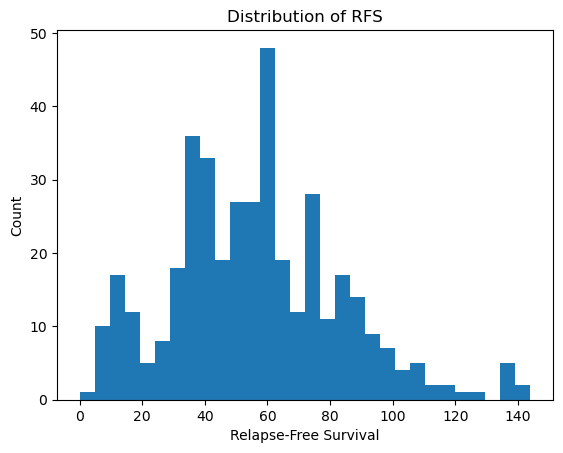

In [30]:
# Data visualization
plt.hist(y.dropna(), bins=30)
plt.xlabel("Relapse-Free Survival")
plt.ylabel("Count")
plt.title("Distribution of RFS")
plt.show()

### 1.2 Feature groups and preprocessing pipeline

In [31]:
# Categorical features (clinical / histology / gene markers)
categorical_features = [
    "ER", "PgR", "HER2", "TrippleNegative", "ChemoGrade",
    "Proliferation", "HistologyType", "LNStatus", "TumourStage", "Gene"
]

# All other columns are treated as numeric
numeric_features = [col for col in X.columns if col not in categorical_features]

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

# Numeric: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical: most frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Column-wise preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

Number of numeric features: 108
Number of categorical features: 10


In [32]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

X_train.shape, X_test.shape

((280, 118), (120, 118))

## 2. Baseline Models

We first establish simple baselines:

- DummyRegressor predicting the mean RFS
- Linear regression with preprocessing

Gives us a reference to beat

In [33]:
def evaluate_model(model, X_train, y_train, X_test, y_test, cv_splits=5):
    """
    Helper to compute CV RMSE/R2 and test RMSE/MAE/R2.

    Parameters:
    model: scikit-learn regressor
        The regression model to evaluate.
    X_train: array-like, shape (n_samples_train, n_features)
        Training feature matrix.
    y_train: array-like, shape (n_samples_train,)
        Training target vector.
    X_test: array-like, shape (n_samples_test, n_features)
        Test feature matrix.
    y_test: array-like, shape (n_samples_test,)
        Test target vector.
    cv_splits: int
        Number of CV splits.
    
    Returns:
    dict
        Dictionary with CV and test metrics.
    """
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    
    # CV RMSE and R2
    cv_rmse = -cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    cv_r2 = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    test_rmse = np.sqrt(mse)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    
    return {
        "CV_RMSE_mean": cv_rmse.mean(),
        "CV_RMSE_std": cv_rmse.std(),
        "CV_R2_mean": cv_r2.mean(),
        "CV_R2_std": cv_r2.std(),
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Test_R2": test_r2,
    }

In [34]:
results_baseline = {}

# DummyRegressor (predicts mean)
dummy = DummyRegressor(strategy="mean")
results_baseline["Dummy (mean)"] = evaluate_model(
    dummy, X_train, y_train, X_test, y_test
)
# Linear Regression with preprocessing
lin_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])
results_baseline["Linear Regression"] = evaluate_model(
    lin_reg, X_train, y_train, X_test, y_test
)

pd.DataFrame(results_baseline).T

/Users/rubenodamo/opt/anaconda3/envs/MLE/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,Test_RMSE,Test_MAE,Test_R2
Dummy (mean),2.658201e+01,2.694787e+00,-1.521270e-02,8.976590e-03,28.155361,22.172252,-0.000386
Linear Regression,7.625711e+06,1.525114e+07,-3.271707e+11,6.543414e+11,995.009689,119.865108,-1248.396119


## 3. Feature Selection & Dimensionality Reduction
### 3.1 Lasso-based feature selection (on preprocessed features)

In [35]:
# Fit preprocessing on training data and transform once for FS experiments
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_proc.shape, len(feature_names)

/Users/rubenodamo/opt/anaconda3/envs/MLE/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


((280, 121), 121)

In [36]:
# Lasso for feature selection
lasso = Lasso(alpha=0.1, max_iter=10000, random_state=RANDOM_STATE)
lasso.fit(X_train_proc, y_train)

lasso_selector = SelectFromModel(lasso, prefit=True)
mask_lasso = lasso_selector.get_support()

must_keep_keywords = ["ER", "HER2", "Gene"]

fs_check = pd.DataFrame({
    "feature": feature_names,
    "selected": mask_lasso
})

print("=== Before forcing, ER / HER2 / Gene selection status ===")
for keyword in must_keep_keywords:
    subset = fs_check[fs_check["feature"].str.contains(keyword)]
    print(f"\nFeatures containing '{keyword}':")
    print(subset if not subset.empty else "  (none)")

for i, name in enumerate(feature_names):
    if any(keyword in name for keyword in must_keep_keywords):
        if not mask_lasso[i]:
            print(f"Forcing LASSO to keep '{name}'")
            mask_lasso[i] = True

selected_features_lasso = np.array(feature_names)[mask_lasso]
print(f"Lasso selected {mask_lasso.sum()} features out of {len(feature_names)}")

selected_features_lasso[:20]

=== Before forcing, ER / HER2 / Gene selection status ===

Features containing 'ER':
           feature  selected
108    cat__ER_1.0     False
110  cat__HER2_1.0      True

Features containing 'HER2':
           feature  selected
110  cat__HER2_1.0      True

Features containing 'Gene':
           feature  selected
120  cat__Gene_1.0      True
Forcing LASSO to keep 'cat__ER_1.0'
Lasso selected 50 features out of 121


array(['num__Age', 'num__original_shape_Elongation',
       'num__original_shape_Flatness',
       'num__original_shape_LeastAxisLength',
       'num__original_shape_MajorAxisLength',
       'num__original_shape_Maximum2DDiameterRow',
       'num__original_shape_Maximum3DDiameter',
       'num__original_shape_MinorAxisLength',
       'num__original_shape_Sphericity',
       'num__original_firstorder_Kurtosis',
       'num__original_firstorder_Maximum',
       'num__original_firstorder_Median',
       'num__original_firstorder_Range',
       'num__original_firstorder_Skewness',
       'num__original_firstorder_Variance',
       'num__original_glcm_ClusterShade',
       'num__original_glcm_ClusterTendency', 'num__original_glcm_Imc1',
       'num__original_gldm_DependenceEntropy',
       'num__original_gldm_DependenceNonUniformity'], dtype=object)

In [37]:
from sklearn.base import BaseEstimator, TransformerMixin

class MaskedFeatureSelector(BaseEstimator, TransformerMixin):
    """
    Simple transformer that applies a fixed boolean mask to the feature matrix.
    This lets us use the *same* LASSO + forced-mask selection inside a Pipeline.
    """
    def __init__(self, mask):
        self.mask = mask

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        mask = np.asarray(self.mask)
        return X[:, mask]

### 3.2 Tree-based feature importance (RandomForestRegressor)

In [38]:
rf_fs = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_fs.fit(X_train_proc, y_train)

importances = rf_fs.feature_importances_
rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

rf_importance_df.head(20)

,feature,importance
26,num__original_firstorder_Range,0.043906
95,num__original_glszm_SizeZoneNonUniformity,0.035289
20,num__original_firstorder_Kurtosis,0.032605
101,num__original_glszm_ZonePercentage,0.028634
21,num__original_firstorder_Maximum,0.028514
0,num__Age,0.028026
19,num__original_firstorder_InterquartileRange,0.027434
32,num__original_firstorder_Variance,0.027263
29,num__original_firstorder_Skewness,0.025416
16,num__original_firstorder_90Percentile,0.024338


In [39]:
# Select top k features based on RF importance
top_k = 40
top_rf_features = rf_importance_df.head(top_k)["feature"].values
top_rf_features[:10]

array(['num__original_firstorder_Range',
       'num__original_glszm_SizeZoneNonUniformity',
       'num__original_firstorder_Kurtosis',
       'num__original_glszm_ZonePercentage',
       'num__original_firstorder_Maximum', 'num__Age',
       'num__original_firstorder_InterquartileRange',
       'num__original_firstorder_Variance',
       'num__original_firstorder_Skewness',
       'num__original_firstorder_90Percentile'], dtype=object)

### 3.3 PCA

In [40]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_proc)
X_test_pca = pca.transform(X_test_proc)

print(f"Original dim: {X_train_proc.shape[1]}, after PCA: {X_train_pca.shape[1]}")

Original dim: 121, after PCA: 18


## 4. Model Comparison

We compare several regression models on different feature representations:
- Full preprocessed features
- Lasso-selected features
- PCA-reduced features

In [41]:
# Lasso-selected feature matrices
X_train_lasso = X_train_proc[:, mask_lasso]
X_test_lasso  = X_test_proc[:, mask_lasso]

print("Full preprocessed:", X_train_proc.shape)
print("Lasso-selected:   ", X_train_lasso.shape)
print("PCA features:     ", X_train_pca.shape)

Full preprocessed: (280, 121)
Lasso-selected:    (280, 50)
PCA features:      (280, 18)


In [42]:
# Define base models with some hyperparameters to compare
base_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),
    "SVR_RBF": SVR(kernel="rbf", C=10, gamma="scale"),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
}

In [43]:
# Helper to compare models on different feature sets
def compare_models_on_features(models, X_tr, y_tr, X_te, y_te, feature_set_name):
    """
    Helper to compute CV RMSE/R2 and test RMSE/MAE/R2 for multiple models.

    Parameters:
    models: dict
        Dictionary of (name, model) pairs to evaluate.
    X_tr: array-like, shape (n_samples_train, n_features)
        Training feature matrix.
    y_tr: array-like, shape (n_samples_train,)
        Training target vector.
    X_te: array-like, shape (n_samples_test, n_features)
        Test feature matrix.
    y_te: array-like, shape (n_samples_test,)
        Test target vector.
    feature_set_name: str
        Name of the feature set (for reporting).

    Returns:
    pd.DataFrame
        DataFrame with evaluation results for each model.
    """
    results = {}
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    for name, model in models.items():
        # Cross-validated RMSE (if neg_root_mean_squared_error works in your sklearn)
        cv_rmse = -cross_val_score(
            model, X_tr, y_tr,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )
        cv_r2 = cross_val_score(
            model, X_tr, y_tr,
            cv=cv,
            scoring="r2",
            n_jobs=-1
        )
        
        # Fit on training subset
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        # Compute test RMSE manually (no squared=False)
        mse = mean_squared_error(y_te, y_pred)
        test_rmse = np.sqrt(mse)
        test_mae = mean_absolute_error(y_te, y_pred)
        test_r2 = r2_score(y_te, y_pred)
        
        results[name] = {
            "Feature_Set": feature_set_name,
            "CV_RMSE_mean": cv_rmse.mean(),
            "CV_RMSE_std": cv_rmse.std(),
            "CV_R2_mean": cv_r2.mean(),
            "CV_R2_std": cv_r2.std(),
            "Test_RMSE": test_rmse,
            "Test_MAE": test_mae,
            "Test_R2": test_r2,
        }
    
    return pd.DataFrame(results).T

In [44]:
# Run comparisons on all feature sets
results_full = compare_models_on_features(
    base_models, X_train_proc, y_train, X_test_proc, y_test, "Full"
)
results_lasso = compare_models_on_features(
    base_models, X_train_lasso, y_train, X_test_lasso, y_test, "Lasso"
)
results_pca = compare_models_on_features(
    base_models, X_train_pca, y_train, X_test_pca, y_test, "PCA"
)

results_all = pd.concat([results_full, results_lasso, results_pca])
results_all

/Users/rubenodamo/opt/anaconda3/envs/MLE/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.610e+01, tolerance: 1.665e+01
  model = cd_fast.enet_coordinate_descent(
/Users/rubenodamo/opt/anaconda3/envs/MLE/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.537e+02, tolerance: 1.633e+01
  model = cd_fast.enet_coordinate_descent(
/Users/rubenodamo/opt/anaconda3/envs/MLE/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

,Feature_Set,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,Test_RMSE,Test_MAE,Test_R2
LinearRegression,Full,7625649.251899,15251013.607323,-327165349192.59259,654330698270.549927,995.009689,119.865108,-1248.396119
Ridge,Full,30.983575,4.703793,-0.381132,0.232351,32.44696,23.962267,-0.328598
ElasticNet,Full,26.998746,2.321559,-0.055965,0.11557,28.258878,21.916407,-0.007756
RandomForest,Full,26.300488,2.197141,0.000619,0.073744,28.173642,22.129061,-0.001686
GradientBoosting,Full,27.78045,1.592288,-0.125006,0.139998,28.949512,22.475337,-0.057616
HistGradientBoosting,Full,26.817691,1.888343,-0.042659,0.094431,28.647049,22.518437,-0.035632
SVR_RBF,Full,26.274317,2.0832,0.003256,0.04691,28.13084,21.990226,0.001355
MLP,Full,38.220235,3.016991,-1.157378,0.441731,35.305597,27.74492,-0.573014
LinearRegression,Lasso,46.022434,39.086579,-3.336784,6.494282,35.777726,25.124777,-0.615366
Ridge,Lasso,26.847264,2.895574,-0.044425,0.151292,30.475859,23.185222,-0.172081


In [45]:
# Show top 15 models by Test RMSE
results_all.sort_values(by="Test_RMSE").head(15)

,Feature_Set,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,Test_RMSE,Test_MAE,Test_R2
SVR_RBF,Lasso,26.028442,2.022015,0.0214,0.049806,27.933623,22.007209,0.015309
RandomForest,PCA,26.498672,2.326426,-0.022245,0.160251,28.108957,22.692847,0.002909
SVR_RBF,Full,26.274317,2.0832,0.003256,0.04691,28.13084,21.990226,0.001355
RandomForest,Full,26.300488,2.197141,0.000619,0.073744,28.173642,22.129061,-0.001686
RandomForest,Lasso,26.155881,2.147421,0.012006,0.061929,28.182765,22.446225,-0.002335
ElasticNet,Full,26.998746,2.321559,-0.055965,0.11557,28.258878,21.916407,-0.007756
SVR_RBF,PCA,26.5752,1.963679,-0.020814,0.053336,28.351465,22.129746,-0.01437
ElasticNet,Lasso,25.99669,2.353001,0.022442,0.094789,28.459974,22.176983,-0.02215
HistGradientBoosting,Full,26.817691,1.888343,-0.042659,0.094431,28.647049,22.518437,-0.035632
ElasticNet,PCA,27.002974,3.286625,-0.049463,0.112739,28.693928,22.365407,-0.039024


## 5. Hyperparameter Tuning for Top Models
### 5.1 GradientBoosting on full preprocessed features

In [46]:
# Hyperparameter tuning for Gradient Boosting Regressor
gb = GradientBoostingRegressor(random_state=RANDOM_STATE)

# Hyperparameter grid for GB
param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 2, 4],
}

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Perform Grid Search CV for GB
grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
)

# Fit Grid Search
grid_gb.fit(X_train_proc, y_train)

# Output best parameters and CV score
print("Best GB params:", grid_gb.best_params_)
print("Best GB CV RMSE:", -grid_gb.best_score_)
best_gb = grid_gb.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100; total time=   0.7s
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=100; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=200; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=200; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=200; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=2, min_samples_leaf=1, n_estimators=200; total time=   1.1s
[CV] END learning_rate=0.05, max_depth=2, min_s

In [47]:
# Evaluate on test set
y_pred_gb = best_gb.predict(X_test_proc)

mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)

print("GB test RMSE:", rmse_gb)
print("GB test MAE:", mean_absolute_error(y_test, y_pred_gb))
print("GB test R2:", r2_score(y_test, y_pred_gb))

GB test RMSE: 28.353512732579414
GB test MAE: 22.008987882644316
GB test R2: -0.014516876408602553


### 5.2 SVR on Lasso-selected features

In [48]:
# Hyperparameter tuning for Support Vector Regressor (SVR)
svr = SVR()

# Hyperparameter grid for SVR
param_grid_svr = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["rbf", "poly"],
    "gamma": ["scale", "auto", 0.01, 0.1],
}

# Cross-validation setup
grid_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid_svr,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
)

# Fit Grid Search
grid_svr.fit(X_train_lasso, y_train)

# Output best parameters and CV score
print("Best SVR params:", grid_svr.best_params_)
print("Best SVR CV RMSE:", -grid_svr.best_score_)
best_svr = grid_svr.best_estimator_

y_pred_svr = best_svr.predict(X_test_lasso)

# Calculate RMSE
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print("SVR test RMSE:", rmse_svr)
print("SVR test MAE:", mean_absolute_error(y_test, y_pred_svr))
print("SVR test R2:", r2_score(y_test, y_pred_svr))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale

In [49]:
from sklearn.base import clone
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.svm import SVR

# Use the best SVR hyperparameters from the grid search
best_svr_params = grid_svr.best_params_
print("Best SVR params:", best_svr_params)

svr_final = SVR(**best_svr_params)

# Final RFS pipeline:
# raw X -> preprocess -> apply fixed LASSO mask (with forced ER/HER2/Gene) -> SVR
final_rfs_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("feature_select", MaskedFeatureSelector(mask_lasso)),
    ("model", svr_final),
])

# Fit on training data for RFS
final_rfs_pipeline.fit(X_train, y_train)

# Sanity check on test set (X_test, y_test)
y_test_pred_final = final_rfs_pipeline.predict(X_test)

mse_final = mean_squared_error(y_test, y_test_pred_final)
rmse_final = np.sqrt(mse_final)

print("Final pipeline test RMSE:", rmse_final)
print("Final pipeline test MAE:", mean_absolute_error(y_test, y_test_pred_final))
print("Final pipeline test R2:", r2_score(y_test, y_test_pred_final))

Best SVR params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Final pipeline test RMSE: 27.82432745149613
Final pipeline test MAE: 22.019689348823864
Final pipeline test R2: 0.022999279079646606


/Users/rubenodamo/opt/anaconda3/envs/MLE/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 6. Final RFS Pipeline (Preprocessing -> Lasso -> SVR)

The final RFS model is implemented as a single scikit-learn pipeline:

1. **Preprocessing**  
   - Median imputation and scaling for numeric features  
   - Most-frequent imputation and one-hot encoding for categorical features  

2. **L1-based feature selection**  
   - `SelectFromModel(Lasso)` applied on the preprocessed feature space  
   - This performs embedded feature selection by shrinking less-informative coefficients to zero  

3. **Support Vector Regression (SVR)**  
   - RBF kernel  
   - Hyperparameters tuned via 5-fold cross-validation on Lasso-selected features  

We first evaluate the pipeline using the original train/test split, then refit the same pipeline on the full dataset for deployment.

In [50]:
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import SVR

from sklearn.svm import SVR

# Use the best SVR hyperparameters from the grid search
best_svr_params = grid_svr.best_params_
print("Best SVR params:", best_svr_params)

svr_final = SVR(**best_svr_params)

# Final RFS pipeline:
# raw X -> preprocess -> apply fixed LASSO mask (with forced ER/HER2/Gene) -> SVR
final_rfs_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("feature_select", MaskedFeatureSelector(mask_lasso)),
    ("model", svr_final),
])

# Fit on training data for RFS
final_rfs_pipeline.fit(X_train, y_train)

y_test_pred_final = final_rfs_pipeline.predict(X_test)

# Calculate final metrics
mse_final = mean_squared_error(y_test, y_test_pred_final)
rmse_final = np.sqrt(mse_final)
mae_final = mean_absolute_error(y_test, y_test_pred_final)
r2_final = r2_score(y_test, y_test_pred_final)

print("Final RFS pipeline performance (train/test split):")
print(f"  Test RMSE: {rmse_final:.4f}")
print(f"  Test MAE:  {mae_final:.4f}")
print(f"  Test R2:   {r2_final:.4f}")

Best SVR params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Final RFS pipeline performance (train/test split):
  Test RMSE: 27.8243
  Test MAE:  22.0197
  Test R2:   0.0230


/Users/rubenodamo/opt/anaconda3/envs/MLE/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [51]:
# Cross-validation on the full pipeline
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rmse = -cross_val_score(
    final_rfs_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
cv_r2 = cross_val_score(
    final_rfs_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
)

print("Final RFS pipeline 5-fold CV on training set:")
print(f"  CV RMSE mean: {cv_rmse.mean():.4f} (std: {cv_rmse.std():.4f})")
print(f"  CV R2 mean:   {cv_r2.mean():.4f} (std: {cv_r2.std():.4f})")

Final RFS pipeline 5-fold CV on training set:
  CV RMSE mean: 25.8859 (std: 2.1562)
  CV R2 mean:   0.0328 (std: 0.0542)


In [52]:
# 6. Deployment version
# NOTE:
# The LASSO mask was created using a preprocessor fitted on X_train.
# Refitting the preprocessor on all X would change the one-hot feature
# space (new categories → new columns), making the mask invalid and
# causing indexing errors.
#
# Therefore, we do not retrain the pipeline on the full dataset.
# We keep the pipeline exactly as fitted on (X_train, y_train) to
# preserve the feature space and required ER/HER2/Gene selections.


# final_rfs_pipeline is fitted on X_train, y_train
final_rfs_pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('feature_select', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
# Sanity check on provided test example dataset

test_example = pd.read_csv("../data/TestDatasetExample.csv")
test_example_clean = test_example.replace(999, np.nan)

# Ensure same feature columns used during training
X_test_example = test_example_clean[X.columns]

y_pred_example = final_rfs_pipeline.predict(X_test_example)

print("Example predictions preview:")
pd.Series(y_pred_example).head()
print("\nPrediction summary statistics:")
print(pd.Series(y_pred_example).describe())

Example predictions preview:

Prediction summary statistics:
count     3.000000
mean     52.874991
std       7.615001
min      45.989957
25%      48.785427
50%      51.580897
75%      56.317507
max      61.054117
dtype: float64


In [54]:
# Export the final_rfs_pipeline using joblib
import joblib

# Export Model for FinalTestRFS file
joblib.dump(final_rfs_pipeline, "models/rfs_final_model.pkl")
print("Model saved successfully!")

Model saved successfully!
